In [1]:
import os
import cv2
import math
import torch
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import classification_report
from torchvision import models, transforms

In [ ]:
"""
Evaluate ResNet18 Baseline on Workspace Images
- Slides a window over each workspace image
- Classifies each patch with the trained ResNet18
- If max softmax prob < CONF_THRESHOLD => predict 'none'
- Matches predictions to ground-truth CSVs with a pixel radius
"""

# ====== Config ======
workspace_dir = "images/workspace-images"
ground_truth_dir = "images/ground-truth-csv"
model_path = "saved_models/resnet18_baseline.pth"
class_list = None  # if None, will load from model checkpoint
PATCH_SIZES = [84, 96, 112, 128]  # similar to your proto pipeline
STRIDE = 20
CONF_THRESHOLD = 0.55       # tweak: higher -> fewer false positives, lower -> more detections
MATCH_RADIUS = 30           # pixels

In [3]:
# ====== Device ======
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====== Load Model ======
ckpt = torch.load(model_path, map_location=device)
img_size = ckpt.get("img_size", 128)
if class_list is None:
    class_list = ckpt.get("class_names", [])
num_classes = len(class_list)

model = models.resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
# ====== Preprocess ======
preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225]),
])

softmax = torch.nn.Softmax(dim=1)

def classify_patch(pil_img):
    """Return (pred_class_name, max_prob)."""
    x = preprocess(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = softmax(logits)
        max_prob, pred_idx = probs.max(dim=1)
    return class_list[pred_idx.item()], float(max_prob.item())

In [5]:
# ====== Helpers ======
def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

all_true, all_pred = [], []

files = [f for f in os.listdir(workspace_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if not files:
    print("No workspace images found.")
    raise SystemExit

for fname in files:
    img_path = os.path.join(workspace_dir, fname)
    gt_path = os.path.join(ground_truth_dir, os.path.splitext(fname)[0] + '.csv')
    if not os.path.exists(gt_path):
        print(f"[!] Ground truth missing for {fname}, skipping.")
        continue

    # Load GT
    gt_df = pd.read_csv(gt_path)
    # Only use classes present in model
    gt_df = gt_df[gt_df['class'].isin(class_list)]
    gt_points_by_class = {c: gt_df[gt_df['class'] == c][['x', 'y']].values.tolist() for c in class_list}

    # Slide window
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W, _ = img_rgb.shape

    detections = []  # (cx, cy, class_name, prob)

    for ps in PATCH_SIZES:
        for y in range(0, H - ps + 1, STRIDE):
            for x in range(0, W - ps + 1, STRIDE):
                patch = img_rgb[y:y+ps, x:x+ps]
                pil = Image.fromarray(cv2.resize(patch, (img_size, img_size)))
                pred_class, prob = classify_patch(pil)
                if prob >= CONF_THRESHOLD:
                    cx, cy = x + ps // 2, y + ps // 2
                    detections.append((cx, cy, pred_class, prob))

    # Greedy matching: for each class, match detections to GT within MATCH_RADIUS
    for c in class_list:
        gt_pts = gt_points_by_class.get(c, [])
        det_pts = [(cx, cy, p) for (cx, cy, pc, p) in detections if pc == c]

        used = set()
        # True positives and false negatives
        for gx, gy in gt_pts:
            matched = False
            best_i, best_dist = -1, 1e9
            for i, (cx, cy, p) in enumerate(det_pts):
                if i in used:
                    continue
                d = euclid((gx, gy), (cx, cy))
                if d < MATCH_RADIUS and d < best_dist:
                    matched, best_i, best_dist = True, i, d
            if matched:
                used.add(best_i)
                all_true.append(c)
                all_pred.append(c)
            else:
                all_true.append(c)
                all_pred.append('none')

        # Remaining detections are false positives
        for i, (cx, cy, p) in enumerate(det_pts):
            if i not in used:
                all_true.append('none')
                all_pred.append(c)

In [6]:
# ====== Report ======
if all_true and all_pred:
    labels = sorted(set(all_true) | set(all_pred))
    print("\n=== Transfer Learning Baseline on Workspace Images ===")
    print(classification_report(all_true, all_pred, labels=labels, zero_division=0))
else:
    print("\n[!] No valid predictions or ground truths processed. Check your folders and file names.")



=== Transfer Learning Baseline on Workspace Images ===
              precision    recall  f1-score   support

       apple       0.01      1.00      0.02       197
      carrot       0.01      1.00      0.02        71
        kiwi       0.00      1.00      0.00       232
        none       0.00      0.00      0.00    174870

    accuracy                           0.00    175370
   macro avg       0.01      0.75      0.01    175370
weighted avg       0.00      0.00      0.00    175370



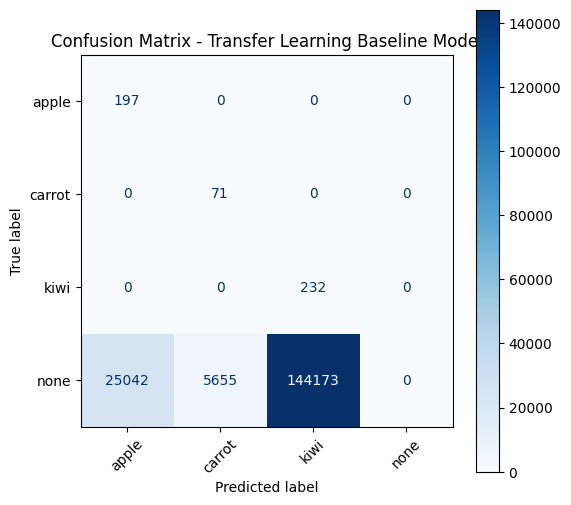

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
labels = sorted(set(all_true) | set(all_pred))  # all classes that appeared
cm = confusion_matrix(all_true, all_pred, labels=labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Transfer Learning Baseline Model")
plt.show()